In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split



In [3]:
data = pd.read_csv('TD_complete_updated_20241219(in) (1).csv', delimiter=';')


In [ ]:
# anonymizing column names
import pandas as pd

# Rename columns to Feature1, Feature2, etc.
data.columns = [f'Feature{i+1}' for i in range(len(data.columns))]

#show the new column names
print(data.columns)

Index(['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5', 'Feature6',
       'Feature7', 'Feature8', 'Feature9', 'Feature10', 'Feature11',
       'Feature12', 'Feature13', 'Feature14', 'Feature15', 'Feature16',
       'Feature17', 'Feature18', 'Feature19', 'Feature20', 'Feature21'],
      dtype='object')


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2782 entries, 0 to 2781
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Feature1   2782 non-null   int64 
 1   Feature2   2782 non-null   int64 
 2   Feature3   2782 non-null   object
 3   Feature4   2782 non-null   object
 4   Feature5   2764 non-null   object
 5   Feature6   2782 non-null   int64 
 6   Feature7   2782 non-null   int64 
 7   Feature8   2782 non-null   object
 8   Feature9   2782 non-null   object
 9   Feature10  2782 non-null   object
 10  Feature11  2782 non-null   object
 11  Feature12  2782 non-null   object
 12  Feature13  2781 non-null   object
 13  Feature14  2781 non-null   object
 14  Feature15  2782 non-null   object
 15  Feature16  2782 non-null   object
 16  Feature17  2782 non-null   object
 17  Feature18  2782 non-null   object
 18  Feature19  2782 non-null   object
 19  Feature20  2782 non-null   object
 20  Feature21  2782 non-null   int

In [6]:
#data

In [ ]:
target_column = 'Feature21'   

In [8]:
# find out columns of object dtypes
object_cols = data.select_dtypes(include=["object"]).columns

# get distinct values
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'Feature3' column:
['Papier-Masse' 'Mischkabel' 'XLPE']
------------------------------
Distinct values in 'Feature4' column:
['29.04.2021' '27.04.2021' '28.04.2021' '20.04.2023' '10.10.2019'
 '11.10.2019' '13.09.2022' '28.09.2021' '21.10.2021' '14.10.2021'
 '05.10.2021' '04.10.2021' '01.11.2021' '23.09.2021' '06.10.2021'
 '30.09.2021' '22.11.2021' '13.09.2021' '20.09.2021' '08.12.2021'
 '07.10.2021' '12.10.2021' '19.10.2021' '18.10.2021' '20.10.2021'
 '13.10.2021' '11.10.2021' '21.09.2021' '08.09.2021' '16.09.2021'
 '10.06.2021' '14.09.2021' '25.11.2021' '07.09.2021' '09.09.2021'
 '07.12.2021' '10.09.2022' '12.09.2022' '27.09.2021' '06.09.2021'
 '14.11.2022' '17.11.2022' '18.04.2023' '19.04.2023' '15.11.2022'
 '14.12.2022' '16.11.2022' '12.12.2022' '13.12.2022' '15.12.2022'
 '17.04.2023' '18.11.2022']
------------------------------
Distinct values in 'Feature5' column:
['09:42:37' '10:04:43' '15:23:37' '15:18:34' '13:58:51' '14:05:00'
 '11:39:48' '09:09:39' '15:58:17

In [9]:
data.isnull().sum()

Feature1      0
Feature2      0
Feature3      0
Feature4      0
Feature5     18
Feature6      0
Feature7      0
Feature8      0
Feature9      0
Feature10     0
Feature11     0
Feature12     0
Feature13     1
Feature14     1
Feature15     0
Feature16     0
Feature17     0
Feature18     0
Feature19     0
Feature20     0
Feature21     0
dtype: int64

In [10]:
enc = LabelEncoder()
for col in object_cols:
    data[col] = enc.fit_transform(data[col])

In [11]:
for col in object_cols:
    print(f"Distinct values in '{col}' column:")
    print(data[col].unique())
    print("-" * 30)

Distinct values in 'Feature3' column:
[1 0 2]
------------------------------
Distinct values in 'Feature4' column:
[50 46 48 38 13 14 20 49 42 24  2  1  0 44  4 51 43 19 39  9  6 17 37 34
 40 21 15 41  8 29 11 23 45  5 10  7 12 16 47  3 25 32 33 36 27 26 30 18
 22 28 31 35]
------------------------------
Distinct values in 'Feature5' column:
[ 32  44 139 138 125 127  79  19 144 114  77 117  29 137  73 128  94  57
 143  17  58 101 136  25  90  54 145 135  13  26 104  35  24  65  27  87
 113  81  43  22  49  86 119  16  23 121  71  40  33  89  98  46  72 118
  48 103 115  67  75  70  30  93 120 142  61   4 110  18 126  91  97  38
 111 140  62  28  63  76  20  59 106  60  92 124  15 108  51 102  56  21
   9   3  52   0  10  11  50   6  36 123   1  47  39   8  37 131   7  42
  85 134 112  96  82 107  45  64 129  69 100  12  83 105 122  78  84 130
  99 133 116  31 132  55  88  66  68  74 141  14  34 146  80  53   5  41
   2  95 109]
------------------------------
Distinct values in 'Feature

           Feature1  Feature2  Feature3  Feature4  Feature5  Feature6  \
Feature1   1.000000  0.722170 -0.248724 -0.030774 -0.055235  0.735285   
Feature2   0.722170  1.000000 -0.398860  0.186089  0.057184  0.964872   
Feature3  -0.248724 -0.398860  1.000000 -0.114434 -0.135012 -0.446214   
Feature4  -0.030774  0.186089 -0.114434  1.000000  0.137035  0.110764   
Feature5  -0.055235  0.057184 -0.135012  0.137035  1.000000  0.058584   
Feature6   0.735285  0.964872 -0.446214  0.110764  0.058584  1.000000   
Feature7   0.001778  0.004016 -0.004112  0.009550  0.001191  0.010597   
Feature8  -0.113364 -0.123283  0.067805 -0.007179  0.010246 -0.122699   
Feature9   0.187193  0.337655 -0.332964 -0.026437 -0.069621  0.363959   
Feature10  0.275036  0.299524 -0.036846 -0.069339 -0.158461  0.313540   
Feature11  0.048991  0.118050 -0.182047 -0.066602 -0.032872  0.149878   
Feature12 -0.038444 -0.047293 -0.077940 -0.045851  0.017913 -0.029037   
Feature13  0.173988  0.338432 -0.314239 -0.035659 -

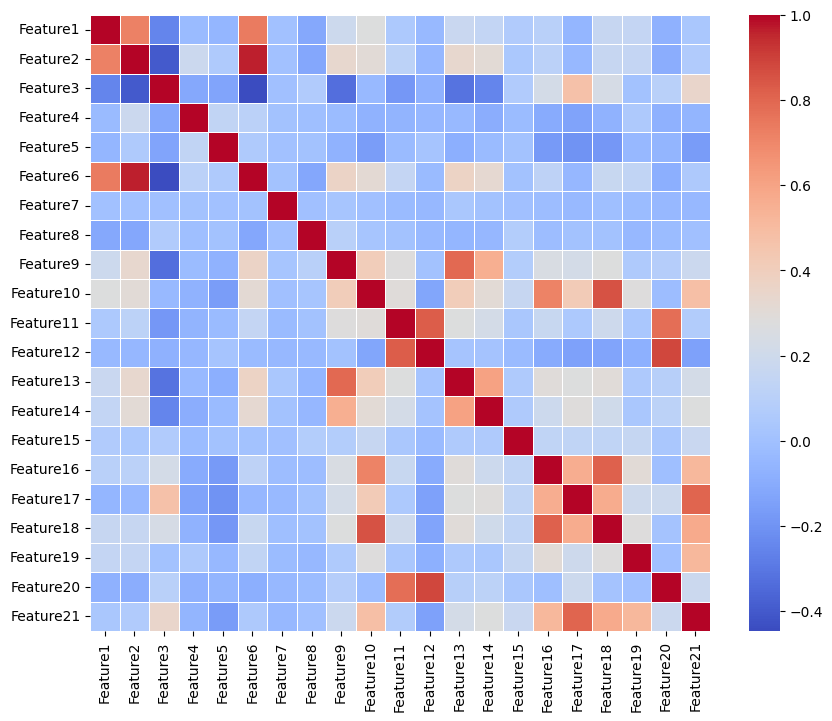

In [12]:
correlation_matrix = data.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

           Feature3  Feature7  Feature8  Feature9  Feature10  Feature11  \
Feature3   1.000000 -0.004112  0.067805 -0.332964  -0.036846  -0.182047   
Feature7  -0.004112  1.000000 -0.001604  0.025057  -0.000298  -0.032471   
Feature8   0.067805 -0.001604  1.000000  0.097695   0.026875   0.011034   
Feature9  -0.332964  0.025057  0.097695  1.000000   0.411067   0.280351   
Feature10 -0.036846 -0.000298  0.026875  0.411067   1.000000   0.289071   
Feature11 -0.182047 -0.032471  0.011034  0.280351   0.289071   1.000000   
Feature12 -0.077940 -0.041777 -0.037984  0.011215  -0.128515   0.827513   
Feature13 -0.314239  0.039171 -0.055425  0.792701   0.409434   0.276586   
Feature14 -0.252652  0.008452 -0.046922  0.556166   0.307696   0.225624   
Feature15  0.066045 -0.000325  0.073721  0.076799   0.161009   0.035267   
Feature20  0.098972 -0.044969 -0.026211  0.080738  -0.017097   0.778677   
Feature21  0.345880 -0.040610 -0.004711  0.184352   0.485169   0.069630   

           Feature12  Fe

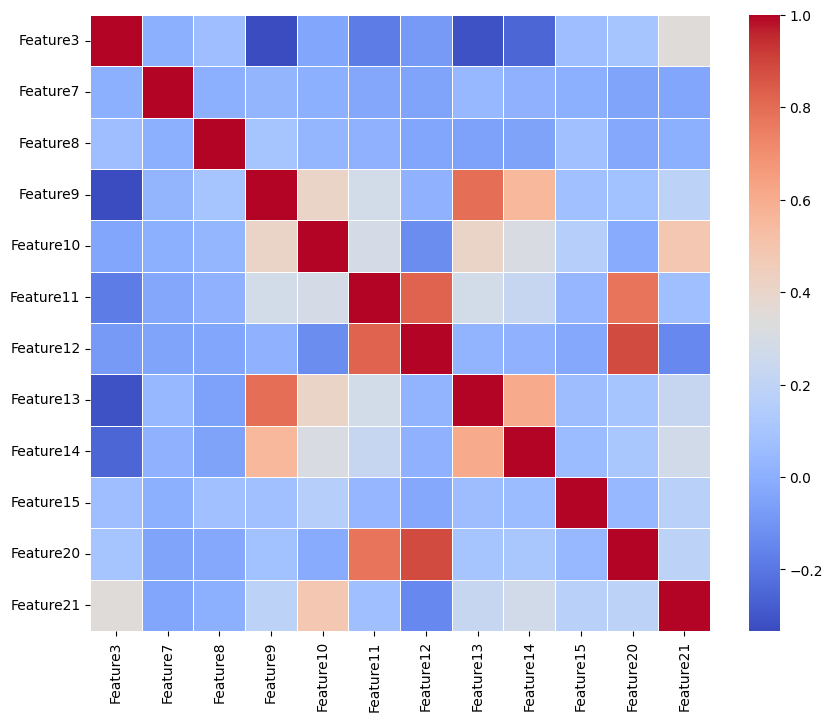

In [13]:
data_for_analysis = data.drop(['Feature1', 'Feature4', 'Feature5', 'Feature6', 'Feature16', 'Feature17', 'Feature18', 'Feature19', 'Feature2'], axis=1)
correlation_matrix = data_for_analysis.corr()
print(correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.show()

In [15]:
#data_for_analysis

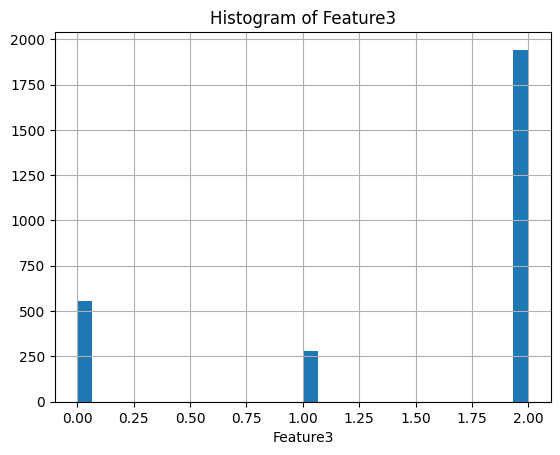

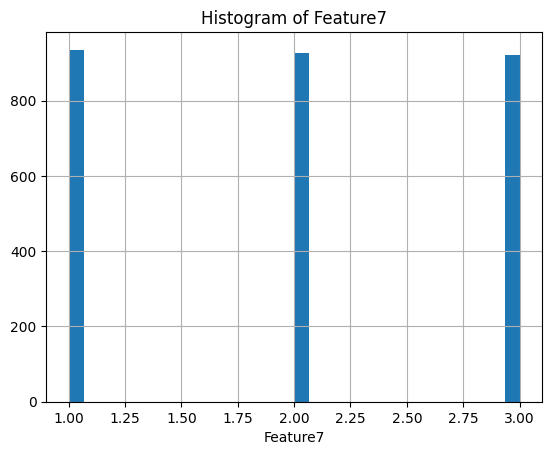

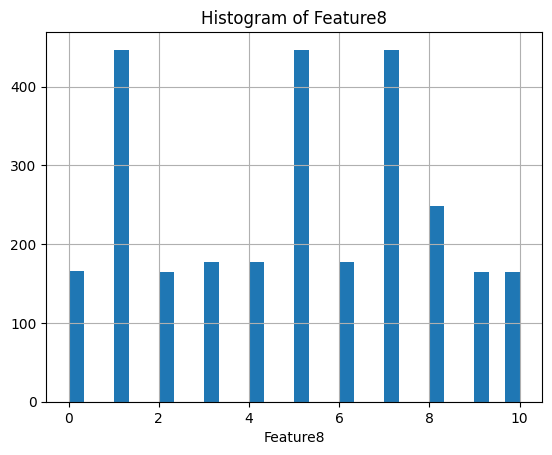

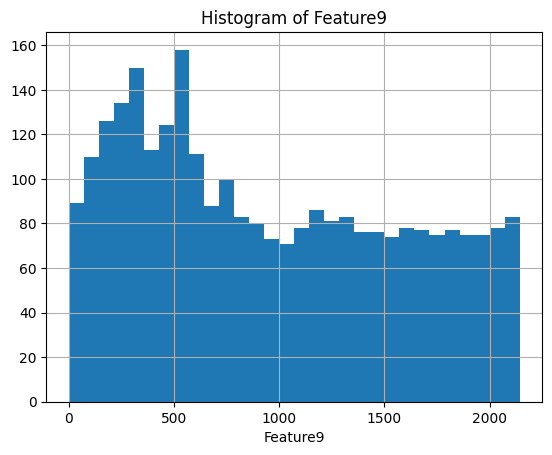

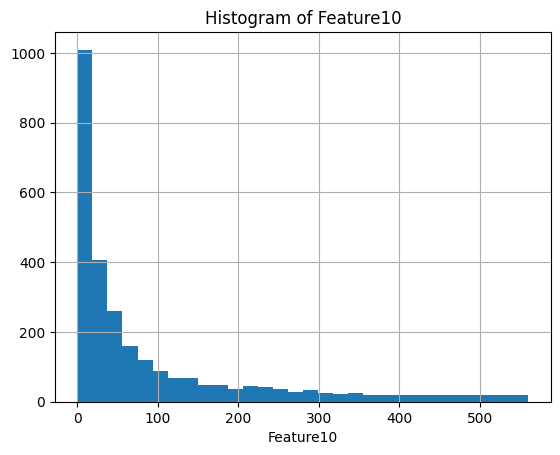

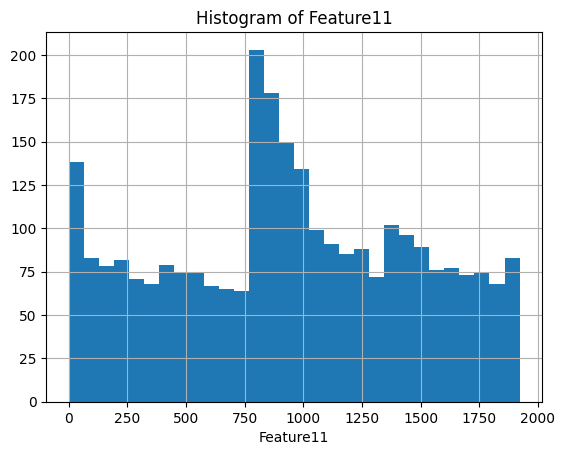

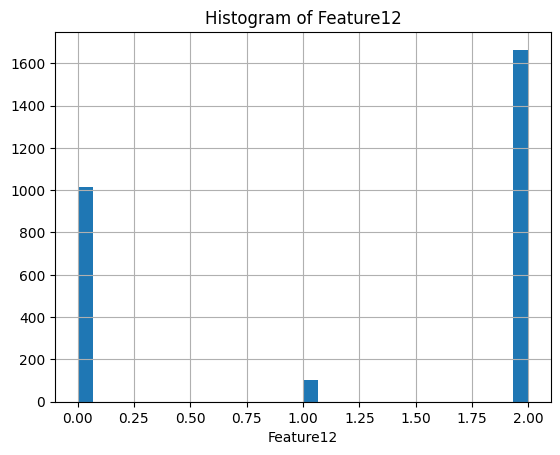

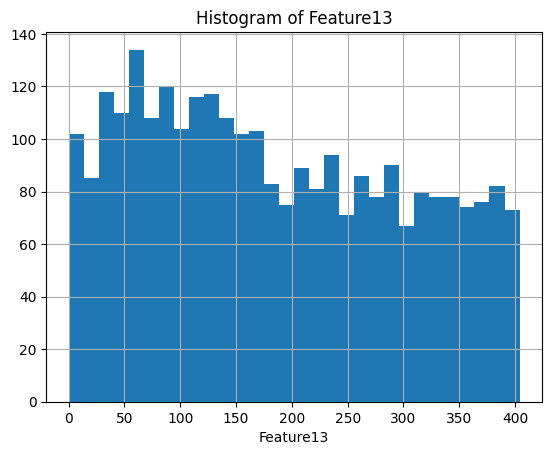

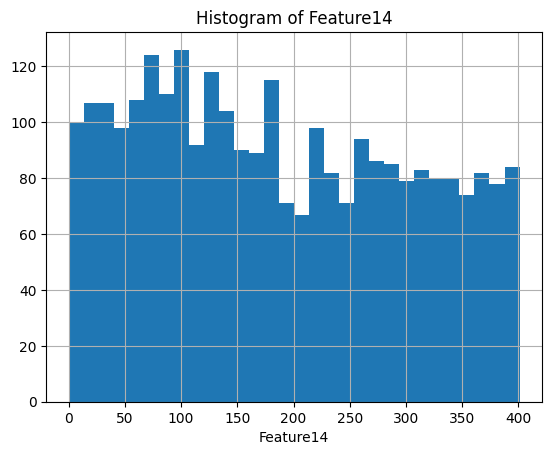

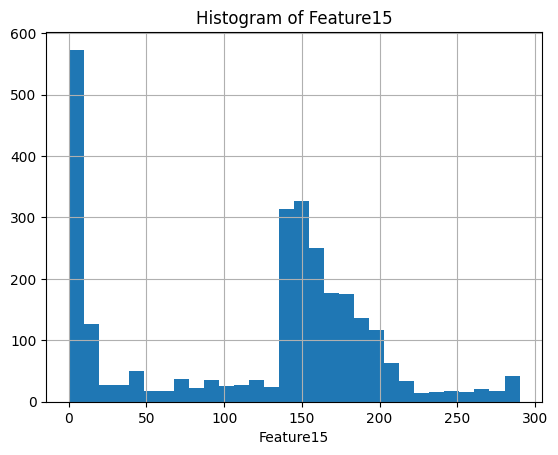

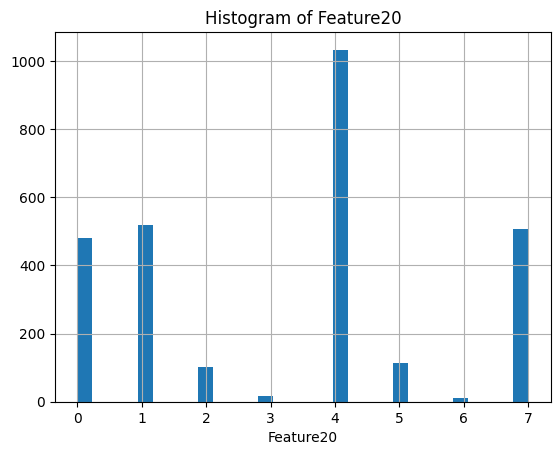

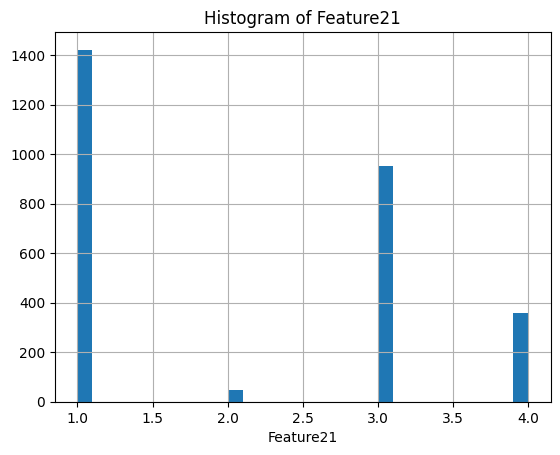

In [16]:
for col in data_for_analysis.columns:
    data_for_analysis[col].hist(bins=30)
    plt.xlabel(col)
    plt.title(f'Histogram of {col}')
    plt.show()

In [17]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column],axis=1)

In [18]:
def make_mi_scores(X, y):
    mi_scores = mutual_info_regression(X.values, y.values)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [19]:
mi_scores = make_mi_scores(x, y)

In [20]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    
    plt.figure(dpi=120, figsize=(18, 18))
    bars = plt.barh(width, scores)
    
    plt.yticks(width, ticks)
    plt.xlabel("MI Scores")
    plt.title("Mutual Information Scores")
    
    # Add value annotations to each bar
    for bar in bars:
        plt.gca().text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
                       f'{bar.get_width():.2f}', ha='left', va='center')
    
    plt.show()

<Figure size 2400x2400 with 0 Axes>

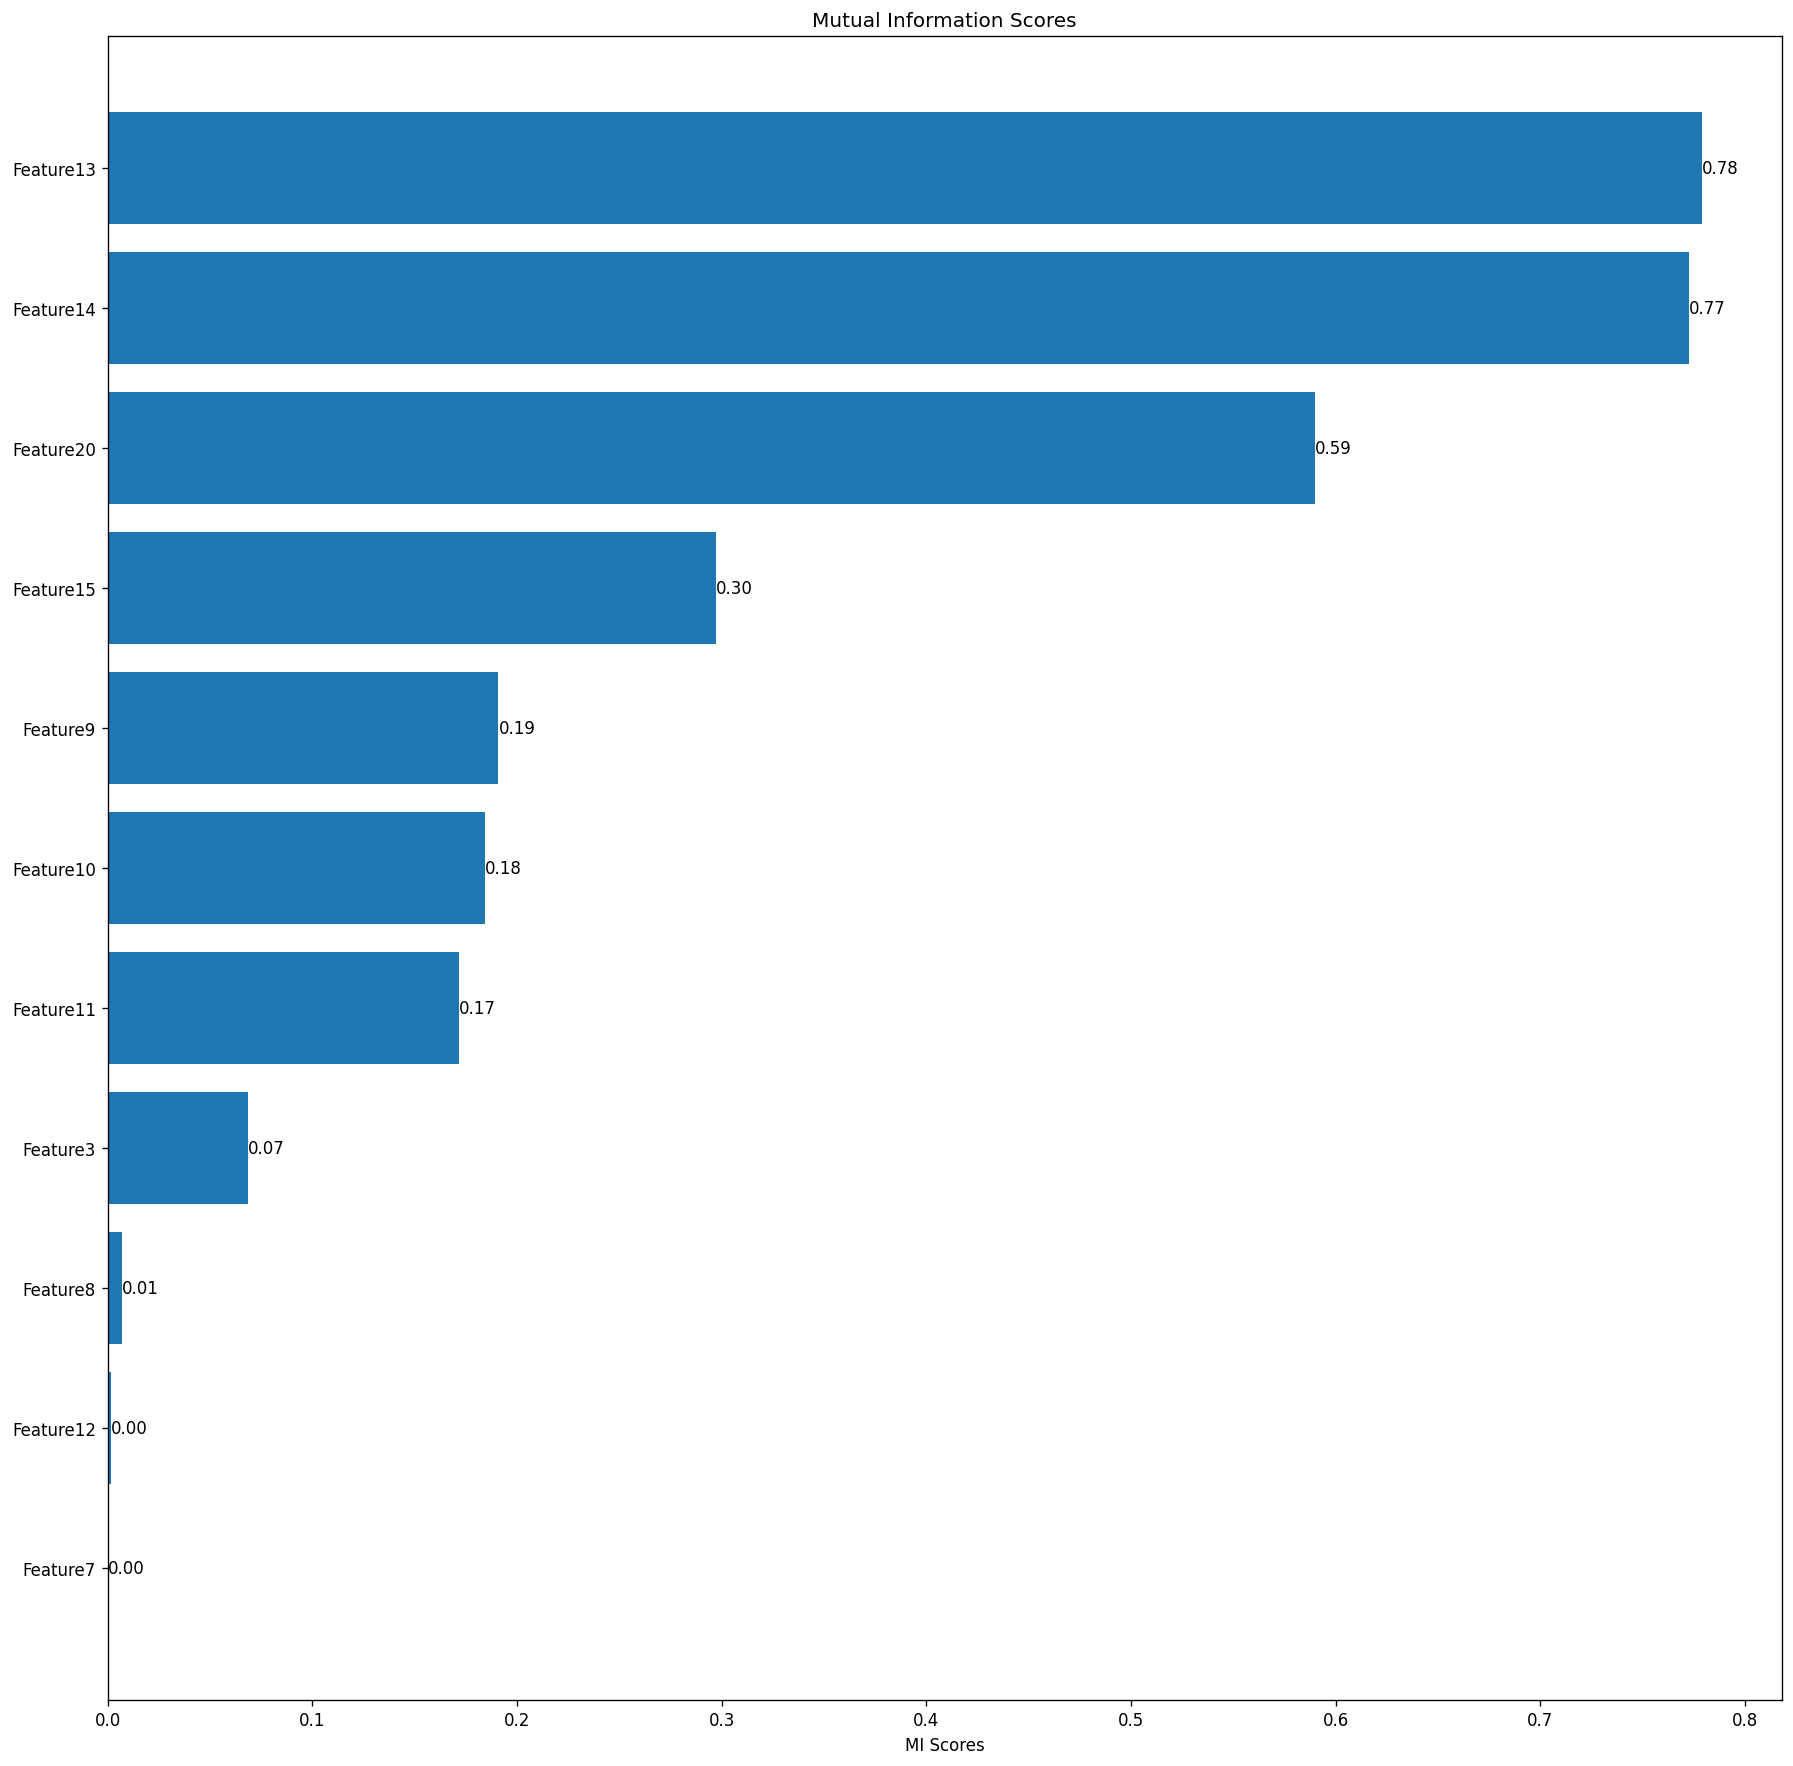

In [21]:
plt.figure(dpi=120, figsize=(20, 20))
plot_mi_scores(mi_scores)

In [22]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Initialize and train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_

# Map feature importance to feature names
feature_importance_df = pd.DataFrame(
    {"feature": x.columns, "importance": feature_importances}
)
feature_importance_df = feature_importance_df.sort_values(
    by="importance", ascending=False
)
print(feature_importance_df)

      feature  importance
10  Feature20    0.600313
9   Feature15    0.162949
5   Feature11    0.103794
4   Feature10    0.031379
3    Feature9    0.022112
8   Feature14    0.021853
6   Feature12    0.021814
0    Feature3    0.017221
7   Feature13    0.015703
2    Feature8    0.001563
1    Feature7    0.001298


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22588\1957462479.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_df['importance'], y=feature_importance_df['feature'], palette='viridis')


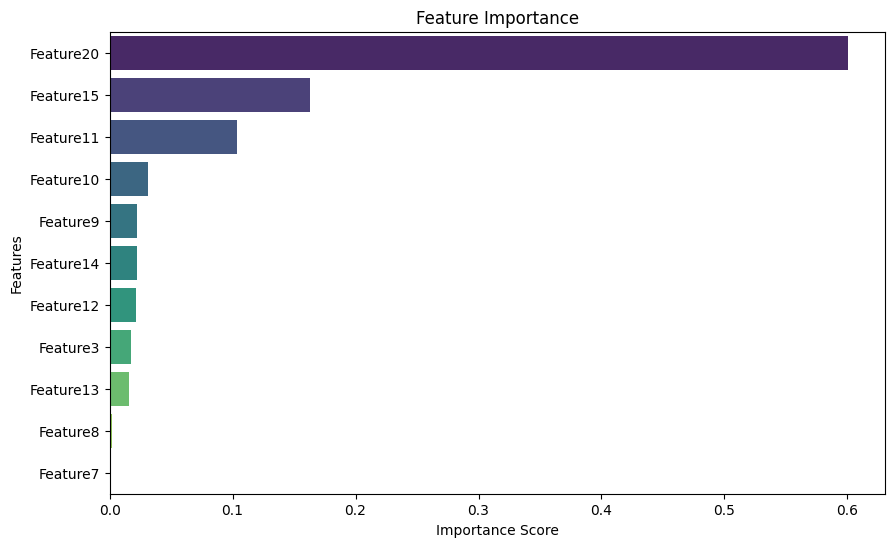

In [23]:
# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df['importance'], y=feature_importance_df['feature'], palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

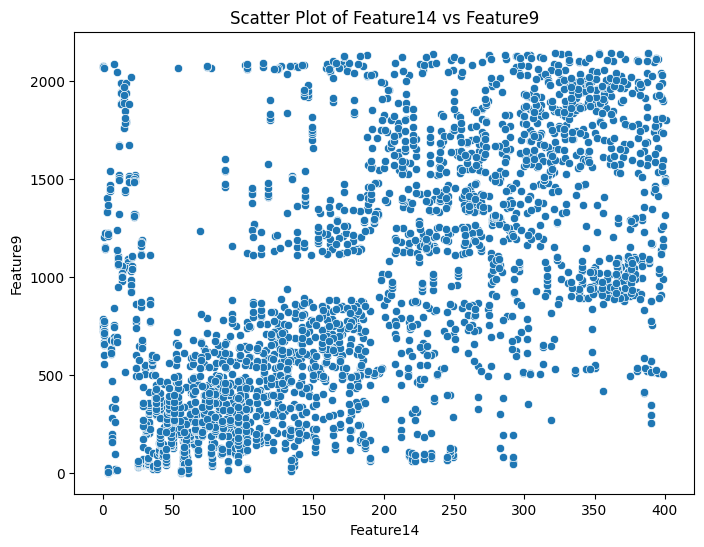

count    2782.000000
mean      959.922717
std       624.093111
min         0.000000
25%       410.250000
50%       860.500000
75%      1496.750000
max      2143.000000
Name: Feature9, dtype: float64

In [24]:
# Scatter plot
feature1 = 'Feature14'  #DTD
feature2 = 'Feature9'   #MTD
plt.figure(figsize=(8, 6))
sns.scatterplot(x=data_for_analysis[feature1], y=data_for_analysis[feature2])
plt.title(f'Scatter Plot of {feature1} vs {feature2}')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.show()
data_for_analysis['Feature9'].describe()

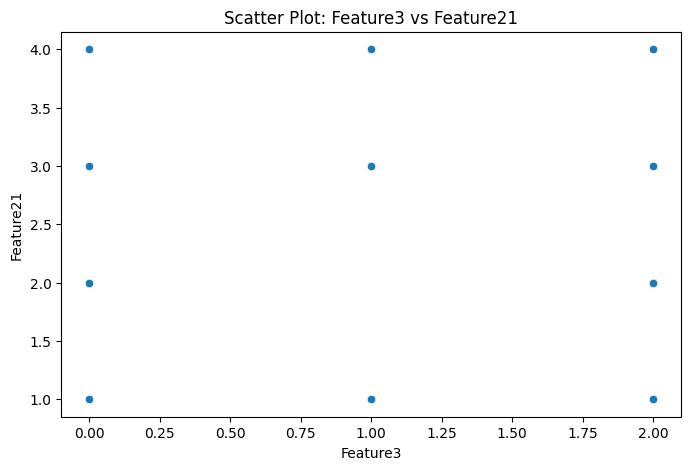

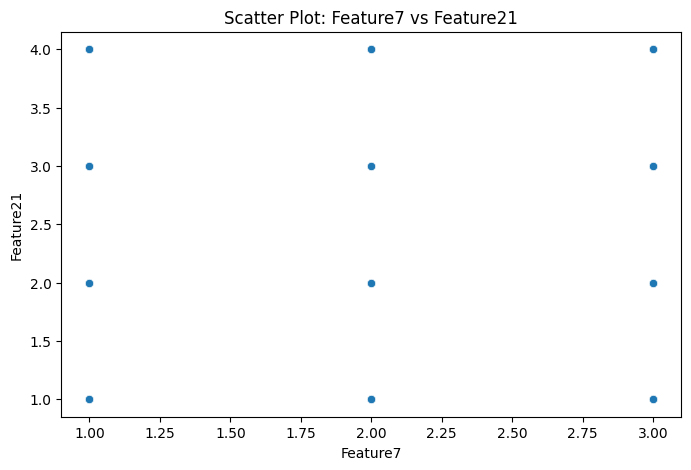

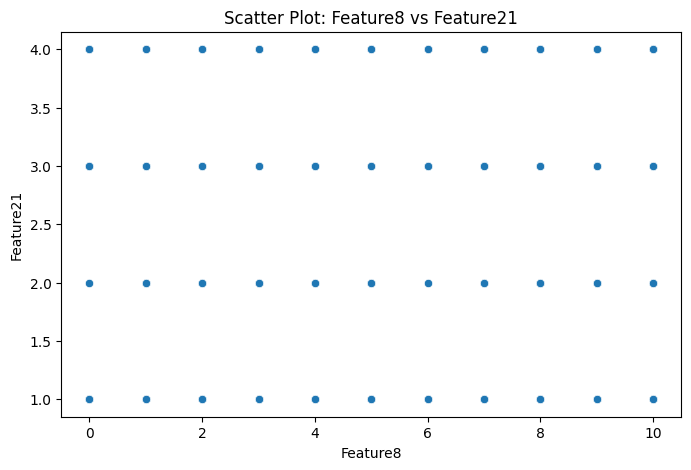

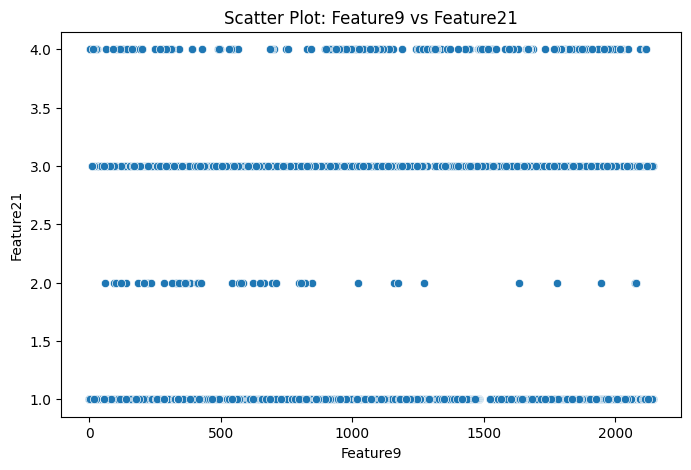

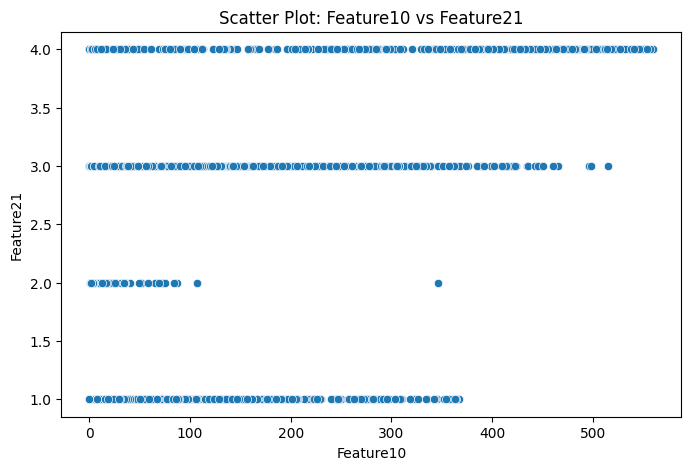

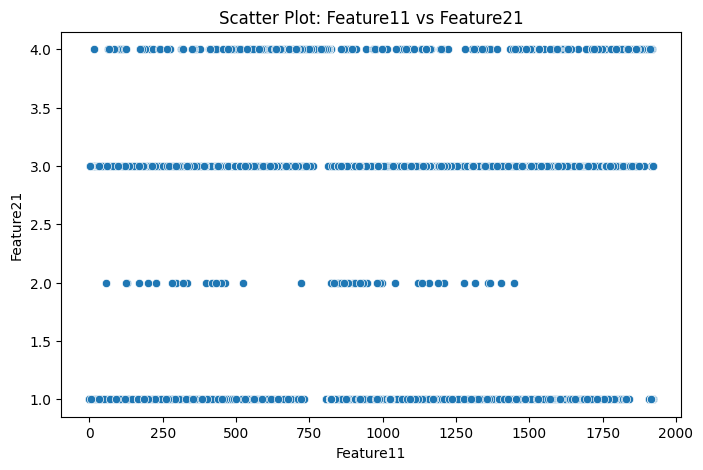

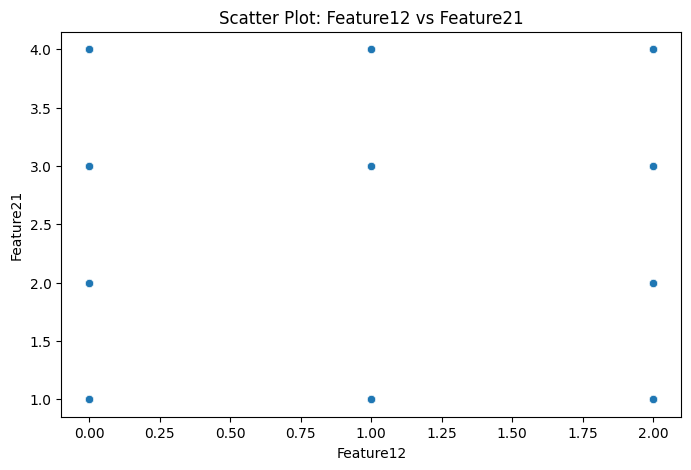

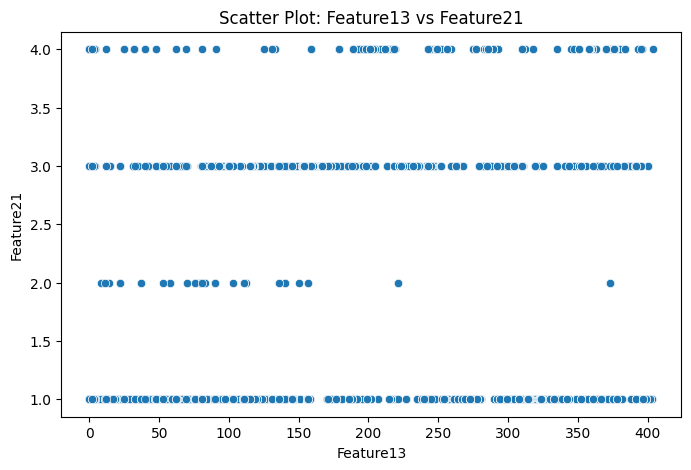

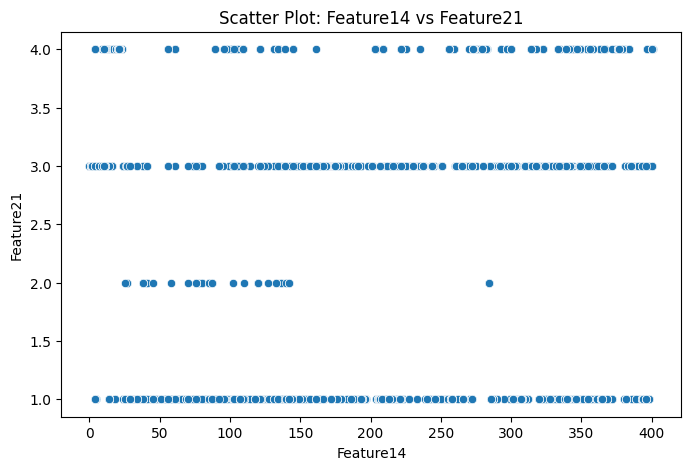

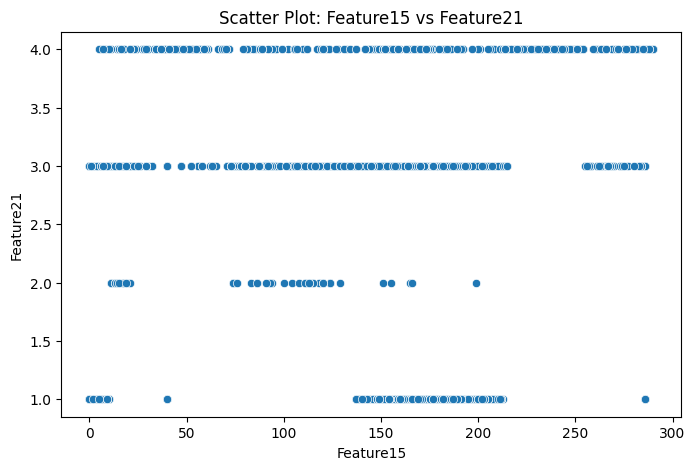

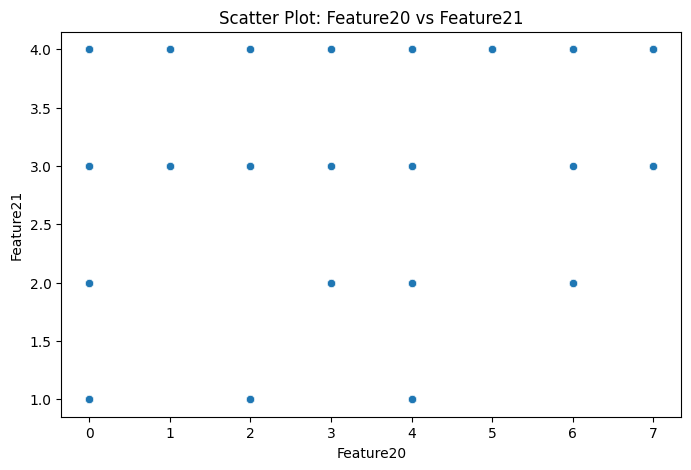

In [25]:
for feature in data_for_analysis.columns:
    if feature != target_column:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=data_for_analysis, x=feature, y=target_column)
        plt.title(f'Scatter Plot: {feature} vs {target_column}')
        plt.show()

In [ ]:
# Drop rows where 'Feature9' > 4000 and 'Feature10' > 5000 to remove the extreme condition
data_for_analysis = data_for_analysis[~((data_for_analysis['Feature9'] > 4000) & (data_for_analysis['Feature10'] > 5000))]

In [27]:
# Get input/output dataframes
y = data_for_analysis[target_column]
x = data_for_analysis.drop([target_column],axis=1)

# Select numerical features
numerical_features = x.select_dtypes(include=['int64', 'float64']).columns
print("Numerical features:", numerical_features)


# Apply log transformation to all numerical features
# Shift values to make them positive
for feature in numerical_features:
    if feature not in object_cols:
        min_value = x[feature].min()
        if min_value <= 0:
            x[feature] = np.log1p(x[feature] - min_value + 1)
        else:
            x[feature] = np.log1p(x[feature])


# Check the transformed dataframe
x.head()


# List of features that were log-transformed
log_transformed_features = [feature for feature in numerical_features if feature not in object_cols]

# Plot the distribution of each log-transformed feature
for feature in log_transformed_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(x[feature], kde=True)
    plt.title(f'Distribution of {feature} after Log Transformation')
    plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22588\1010155807.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[3.95124372 3.66356165 4.4308168  ... 4.70048037 4.87519732 4.97673374]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22588\1010155807.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[7.6666902  7.38274645 6.27098843 ... 2.30258509 2.77258872 2.56494936]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22588\1010155807.py:10: FutureWarni

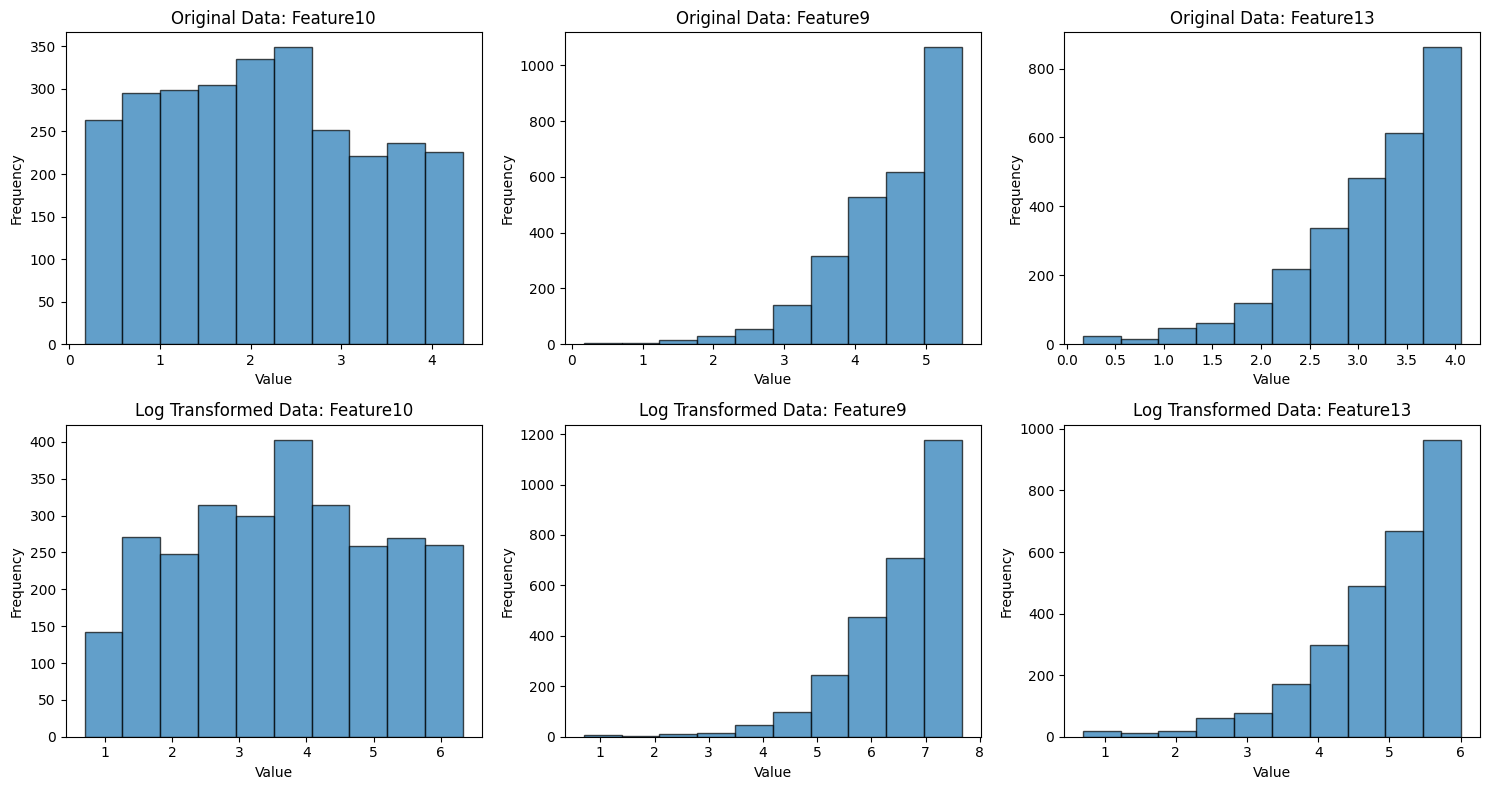

In [28]:
# Define numerical features
numerical_features = ['Feature10', 'Feature9', 'Feature13']

# Define the safe log transform function
def safe_log_transform(series):
    min_value = series.min()
    return np.log1p(series - min_value + 1) if min_value <= 0 else np.log1p(series)

# Apply log transformation with safe_log_transform
data_for_analysis.loc[:, numerical_features] = data_for_analysis[numerical_features].apply(safe_log_transform)

# Plot original vs. transformed data
fig, axes = plt.subplots(2, len(numerical_features), figsize=(15, 8))
titles = ["Original Data", "Log Transformed Data"]

for i, col in enumerate(numerical_features):
    for j, (data, title) in enumerate(zip(
        [data_for_analysis[col] - np.log1p(data_for_analysis[col]), data_for_analysis[col]], titles
    )):
        axes[j, i].hist(data, bins=10, edgecolor='k', alpha=0.7)
        axes[j, i].set_title(f"{title}: {col}")
        axes[j, i].set_xlabel("Value")
        axes[j, i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [29]:
# Standard deviation before scaling
x.std()

Feature3       0.807080
Feature7       0.816699
Feature8       2.974251
Feature9     624.093111
Feature10    132.026334
Feature11    528.339298
Feature12      0.953905
Feature13    115.445135
Feature14    115.474037
Feature15     78.378941
Feature20      2.398766
dtype: float64

In [30]:
# apply scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(x)
x_standardized = pd.DataFrame(scaled_features, columns=x.columns)

In [31]:
# standard deviation after scaling
x_standardized.std()

Feature3     1.00018
Feature7     1.00018
Feature8     1.00018
Feature9     1.00018
Feature10    1.00018
Feature11    1.00018
Feature12    1.00018
Feature13    1.00018
Feature14    1.00018
Feature15    1.00018
Feature20    1.00018
dtype: float64

In [32]:
x_standardized.columns

Index(['Feature3', 'Feature7', 'Feature8', 'Feature9', 'Feature10',
       'Feature11', 'Feature12', 'Feature13', 'Feature14', 'Feature15',
       'Feature20'],
      dtype='object')

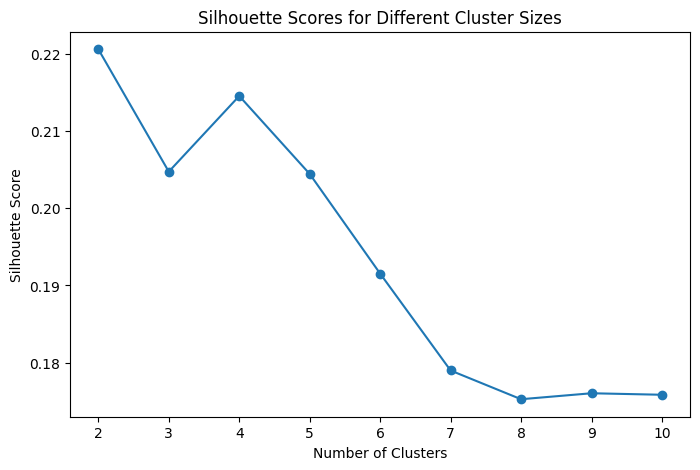

In [33]:
silhouette_scores = []
cluster_range = range(2, 11)

# Loop through cluster sizes
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(x_standardized)
    
    # Check if clustering was successful (i.e., at least 2 clusters)
    if len(set(kmeans_labels)) > 1:
        score = silhouette_score(x_standardized, kmeans_labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(-1)  # If not successful, add a low score

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title("Silhouette Scores for Different Cluster Sizes")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [34]:
# Define number of clusters
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(x_standardized)

d:\master Automation & IT\winter semester 2024\case study Bartz\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


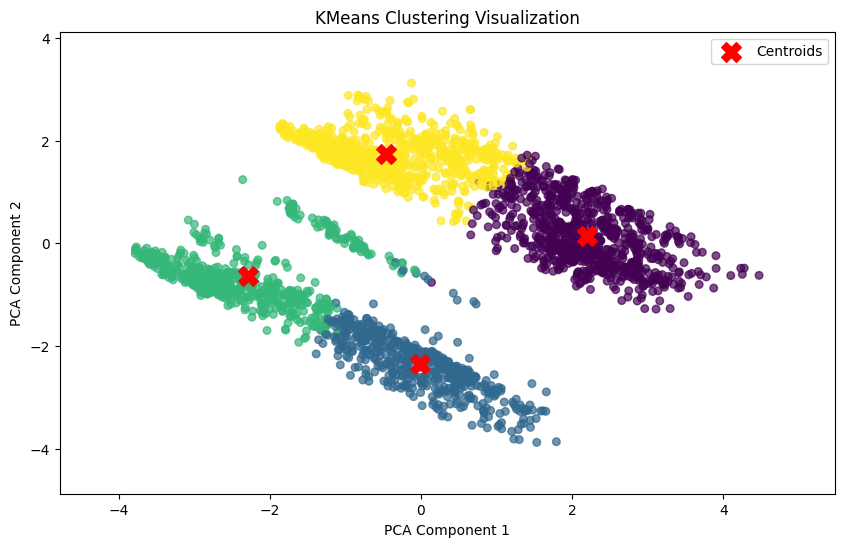

KMeans Silhouette Score: 0.2146


In [35]:
# Apply PCA to reduce features to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_standardized)

# Transform the KMeans centroids using the same PCA transformation
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plot the PCA-transformed data points
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30, alpha=0.7)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("KMeans Clustering Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.xlim(X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1)
plt.ylim(X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1)
plt.show()

# Evaluate KMeans silhouette score for final clustering
kmeans_silhouette = silhouette_score(x_standardized, kmeans_labels)
print(f"KMeans Silhouette Score: {kmeans_silhouette:.4f}")

#### Gaussian Mixture Models

Best Silhouette Score: 0.1668 with 3 clusters


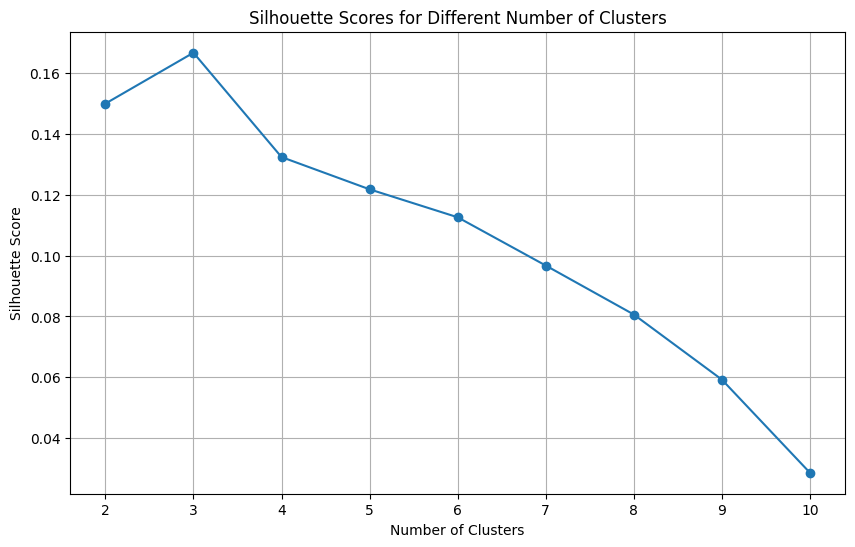

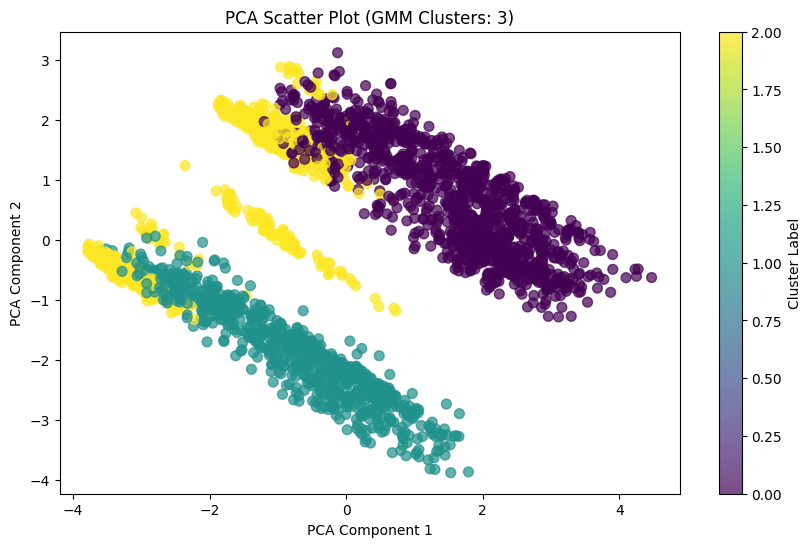

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Function to find the best number of clusters based on silhouette score
def gmm_clustering(X, max_clusters=10):
    best_score = -1
    best_n_clusters = 0
    silhouette_scores = []

    # Test different numbers of clusters
    for n_clusters in range(2, max_clusters + 1):
        gmm = GaussianMixture(n_components=n_clusters, random_state=20)
        labels = gmm.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)

        if score > best_score:
            best_score = score
            best_n_clusters = n_clusters

    print(f"Best Silhouette Score: {best_score:.4f} with {best_n_clusters} clusters")

    # Plot silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
    plt.title("Silhouette Scores for Different Number of Clusters")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

    # Return the best model
    best_gmm = GaussianMixture(n_components=best_n_clusters, random_state=20)
    best_gmm.fit(X)
    return best_gmm, best_n_clusters

# Apply the GMM clustering and find the best number of clusters
gmm_model, n_clusters = gmm_clustering(x_standardized)

# Get the labels from the best GMM model
labels = gmm_model.predict(x_standardized)

# Perform PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_standardized)

# Plot the PCA scatter plot with clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title(f"PCA Scatter Plot (GMM Clusters: {n_clusters})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster Label")
plt.show()


### Hierarchical Clustering

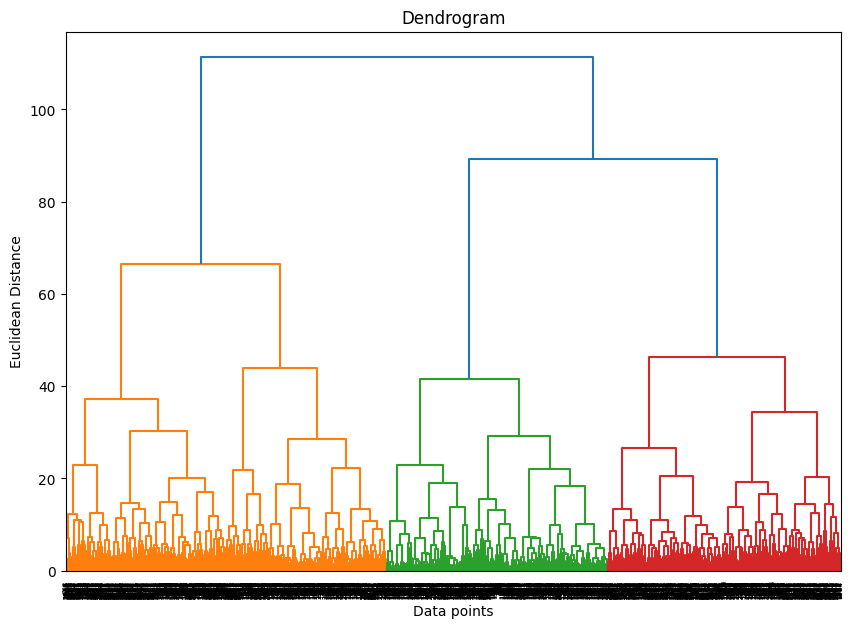

   Feature3  Feature7  Feature8  Feature9  Feature10  Feature11  Feature12  \
0  -0.61651 -1.218058 -1.303899  1.881592  -0.349829   1.058716   0.804662   
1  -0.61651 -1.218058  0.713778  1.035412  -0.448312   0.791794   0.804662   
2  -0.61651 -1.218058  0.041219 -0.693808  -0.107409   0.988672   0.804662   
3  -0.61651 -1.218058  1.050058  1.896015  -0.349829   0.577878   0.804662   
4  -0.61651  0.006603 -1.303899  0.976115  -0.372555   0.988672   0.804662   

   Feature13  Feature14  Feature15  Feature20  Cluster  
0   1.039741   1.744052  -0.521565   1.556615        0  
1   1.039741   1.744052  -1.376540   1.556615        0  
2   1.039741   1.744052  -0.610891   1.556615        0  
3   1.039741   1.744052  -1.338258   1.556615        0  
4   1.178360   1.735391  -1.325497   1.556615        0  


In [ ]:
# Step 1: Import required libraries
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Step 2: Create the linkage matrix (using the 'ward' method)
Z = linkage(x_standardized, method='ward')

# Step 3: Plot the Dendrogram to visualize the clusters
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidean Distance')
plt.show()

# Step 4: Determine the number of clusters (it can be choosed from the Dendrogram)
# For example, let's assume we choose 4 clusters (we can adjust this based on the dendrogram)
optimal_clusters = 4

# Step 5: Perform Hierarchical Clustering with the chosen number of clusters
hc = AgglomerativeClustering(n_clusters=optimal_clusters, linkage='ward')
clusters = hc.fit_predict(x_standardized)

# Step 6: Add the cluster labels to the original dataset
x_standardized['Cluster'] = clusters

# Display the first few rows with the cluster labels
print(x_standardized.head())

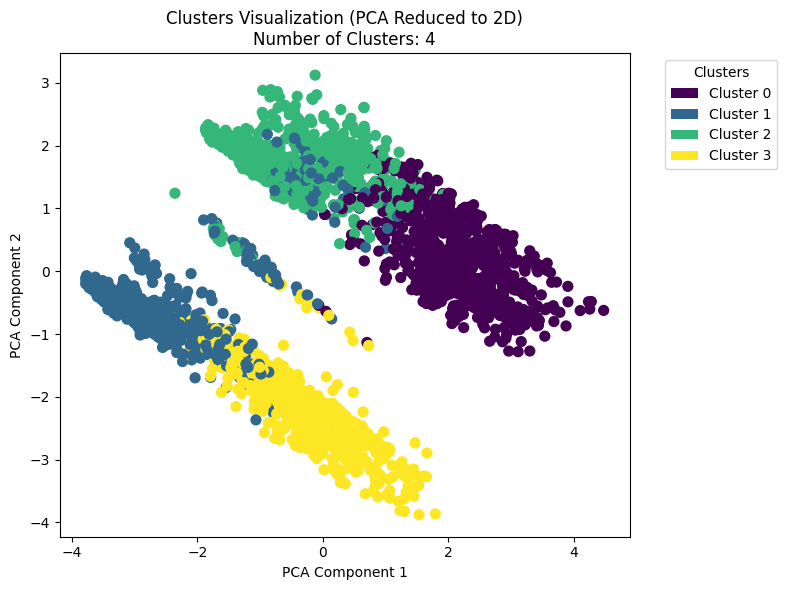

Hierarchical Silhouette Score: 0.1941552560920438


In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Apply PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(x_standardized.drop(columns='Cluster'))

# Calculate the Silhouette Score
silhouette_avg = silhouette_score(x_standardized.drop(columns='Cluster'), x_standardized['Cluster'])

# Create a scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1], c=x_standardized['Cluster'], cmap='viridis', s=50)

# Extract the number of clusters
unique_clusters = np.unique(x_standardized['Cluster'])
num_clusters = len(unique_clusters)

# Add a title with the number of clusters
plt.title(f'Clusters Visualization (PCA Reduced to 2D)\nNumber of Clusters: {num_clusters}')

# Add labels for the axes
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Create a legend for cluster colors
legend_elements = [
    Patch(facecolor=scatter.cmap(scatter.norm(cluster)), label=f'Cluster {cluster}')
    for cluster in unique_clusters
]
plt.legend(handles=legend_elements, title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()

print(f"Hierarchical Silhouette Score: {silhouette_avg}")

### Encode step voltage
log transformation first and then do the std deviation

### Supervised Modelling

#### XGBoost

In [39]:
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

def xgboost_classifier(X, y, objective='multi:softmax', learning_rate=0.1, n_estimators=100):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create XGBClassifier with given parameters
    model = XGBClassifier(
        objective=objective,
        learning_rate=learning_rate,
        max_depth=4,
        n_estimators=n_estimators,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    ## Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.9120
F1 Score: 0.9075


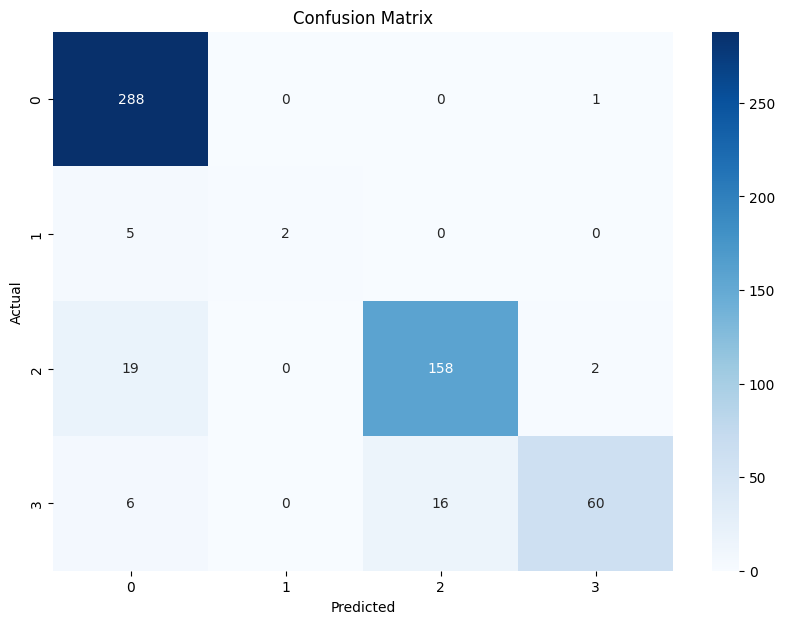

<Figure size 1000x600 with 0 Axes>

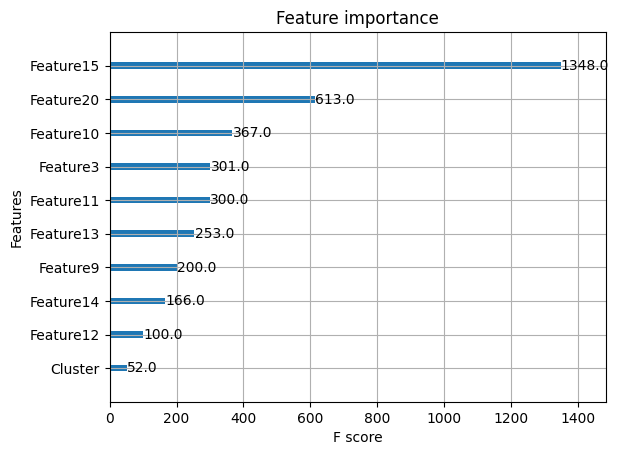

In [40]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = xgboost_classifier(x_standardized, y_adjusted, objective='multi:softmax', learning_rate=0.001, n_estimators=100)

# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(model)
plt.show()


### Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier

def random_forest_classifier(X, y, n_estimators=100, criterion='gini'):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create RandomForestClassifier with given parameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=1,
        random_state=20
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


Accuracy: 0.9390
F1 Score: 0.9353


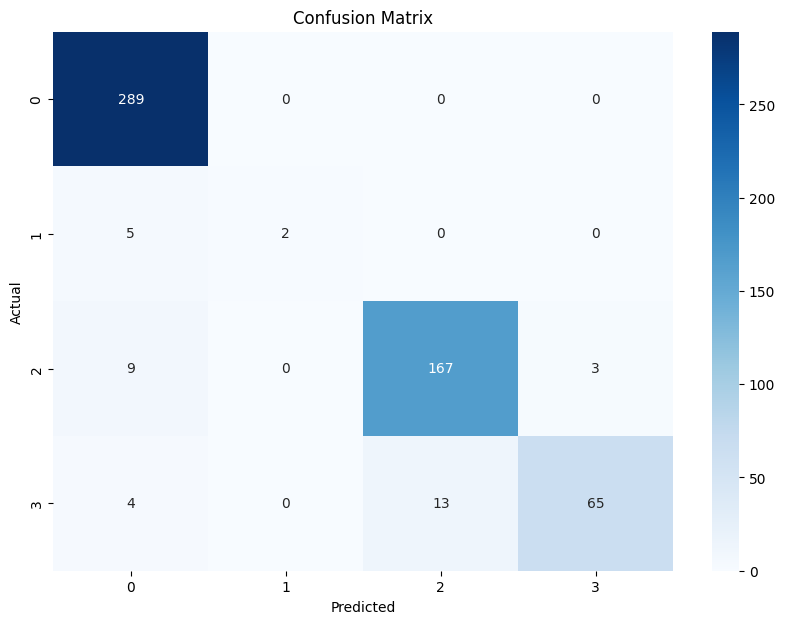

In [42]:
y_adjusted = y.values.ravel() - 1

model, acc, f1, cm = random_forest_classifier(x_standardized, y_adjusted, n_estimators=100, criterion='gini')


      Feature  Importance
10  Feature20    0.273398
8   Feature14    0.145967
0    Feature3    0.138293
4   Feature10    0.121052
9   Feature15    0.094348
7   Feature13    0.076606
5   Feature11    0.051301
3    Feature9    0.037507
11    Cluster    0.025437
6   Feature12    0.020850
2    Feature8    0.010079
1    Feature7    0.005160


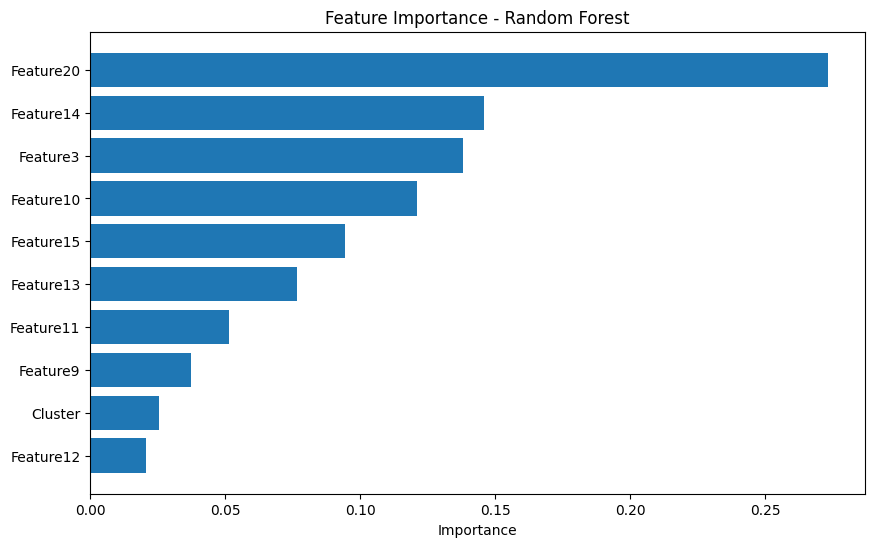

In [43]:
importance_scores = model.feature_importances_
# Create a DataFrame to sort the scores
feature_importance_df = pd.DataFrame({
    'Feature': x_standardized.columns,
    'Importance': importance_scores
})

# Sort the DataFrame by importance
sorted_features = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display sorted feature importance
print(sorted_features)

# Plot top 10 important features
plt.figure(figsize=(10, 6))
plt.barh(sorted_features['Feature'][:10][::-1], sorted_features['Importance'][:10][::-1])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

### KNN 

In [44]:
from sklearn.neighbors import KNeighborsClassifier

def knn_classifier(X, y, n_neighbors=5, metric='minkowski', p=2):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Create KNN classifier with given parameters
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        p=p
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return model, accuracy, f1, cm


In [45]:
from sklearn.model_selection import GridSearchCV

def knn_hyperparameter_tuning(X, y):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
    
    # Define the parameter grid
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2]
    }
    
    # Create a KNN model
    knn = KNeighborsClassifier()
    
    # Perform GridSearchCV
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    # Best parameters and score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Score:", grid_search.best_score_)
    
    return grid_search.best_estimator_


Accuracy: 0.8797
F1 Score: 0.8731


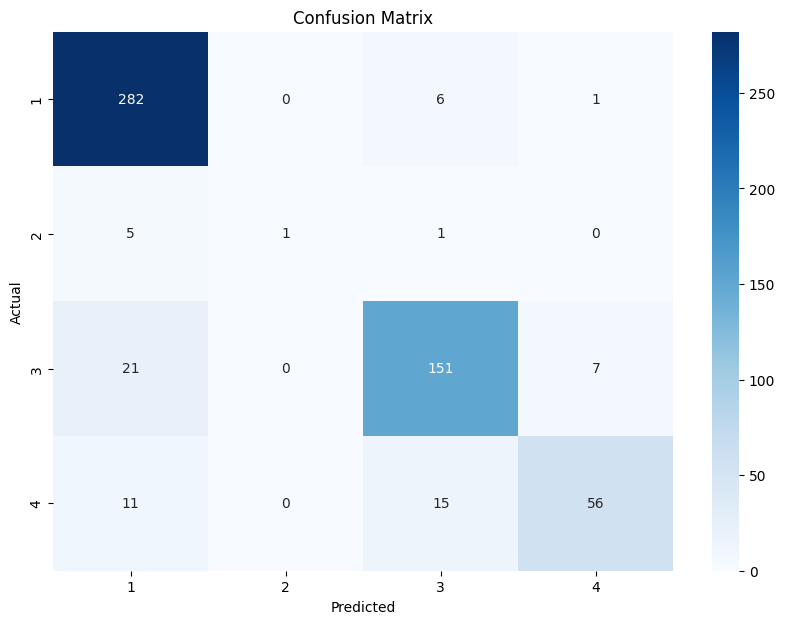

In [46]:
model, acc, f1, cm = knn_classifier(x_standardized, y, n_neighbors=5, metric='minkowski', p=1)

### Progressive Validation

In [47]:
def progressive_validation(model, X, y):
    # Split the dataset into 80% train+validation and 20% test
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=20, stratify=y)

    # Define the progressive splits (20%, 40%, 60%, 80%)
    splits = [0.2, 0.4, 0.6, 0.8]
    results = []

    for split in splits:
        # Calculate the number of samples for the current split
        split_size = int(len(X_train_val) * split)

        # Subset the training data
        X_train, y_train = X_train_val[:split_size], y_train_val[:split_size]

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions on the test set
        y_pred = model.predict(X_test)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        cm = confusion_matrix(y_test, y_pred)

        # Store the results
        results.append({
            'split': f'{int(split * 100)}% train / 20% test',
            'accuracy': accuracy,
            'f1_score': f1,
            'confusion_matrix': cm
        })

        # Plot the confusion matrix
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
        plt.title(f"Confusion Matrix for {int(split * 100)}% Train / 20% Test")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        # Print results
        print(f"Results for {int(split * 100)}% train / 20% test:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print("-" * 40)
    
    return results


KNN Results:


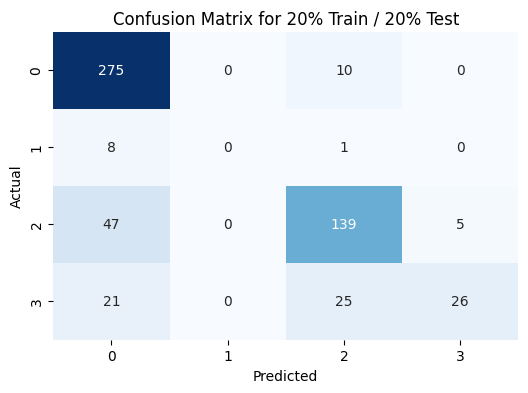

Results for 20% train / 20% test:
Accuracy: 0.7899
F1 Score: 0.7682
----------------------------------------


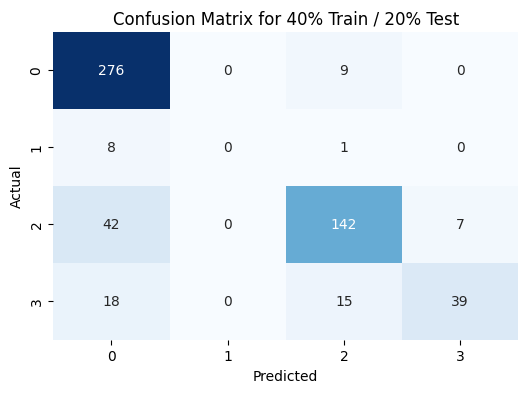

Results for 40% train / 20% test:
Accuracy: 0.8205
F1 Score: 0.8065
----------------------------------------


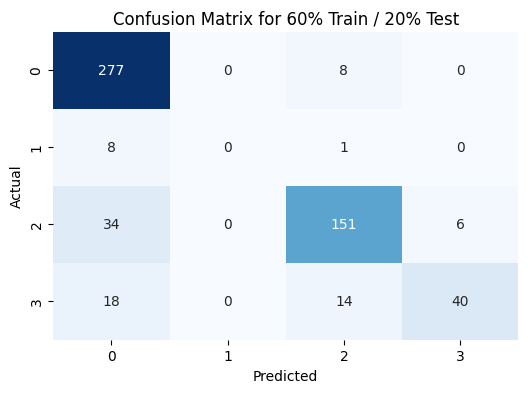

Results for 60% train / 20% test:
Accuracy: 0.8402
F1 Score: 0.8271
----------------------------------------


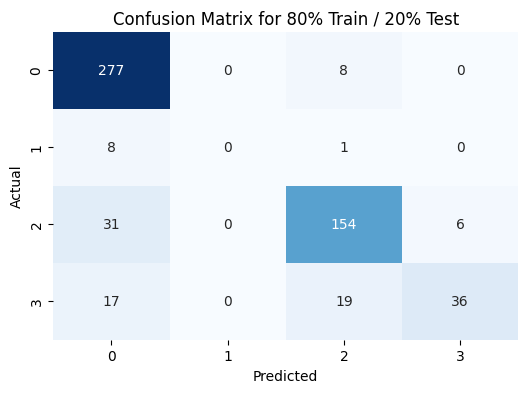

Results for 80% train / 20% test:
Accuracy: 0.8384
F1 Score: 0.8235
----------------------------------------

Random Forest Results:


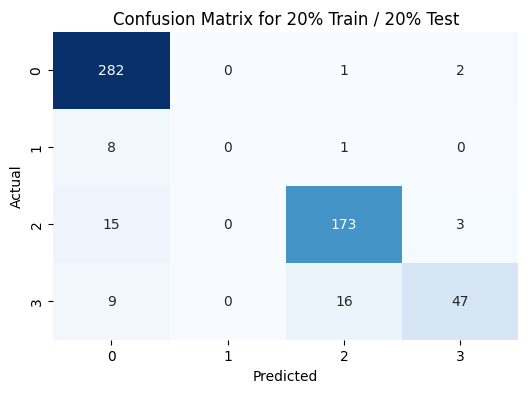

Results for 20% train / 20% test:
Accuracy: 0.9013
F1 Score: 0.8904
----------------------------------------


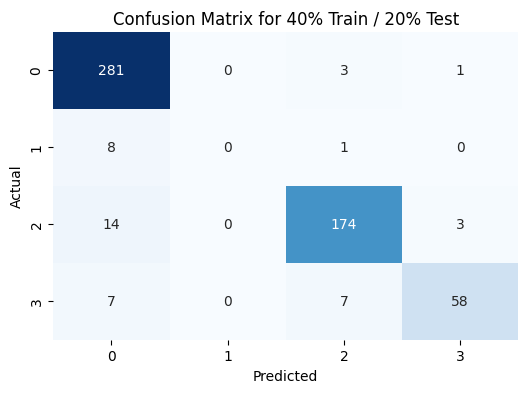

Results for 40% train / 20% test:
Accuracy: 0.9210
F1 Score: 0.9126
----------------------------------------


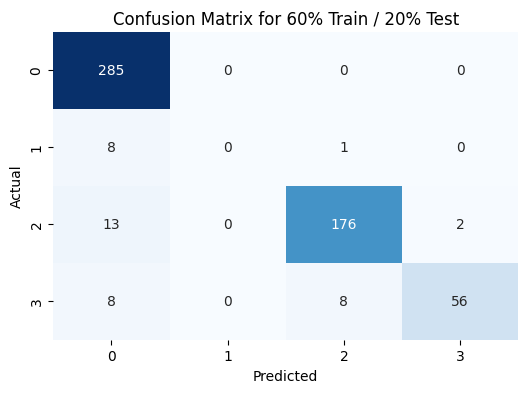

Results for 60% train / 20% test:
Accuracy: 0.9282
F1 Score: 0.9193
----------------------------------------


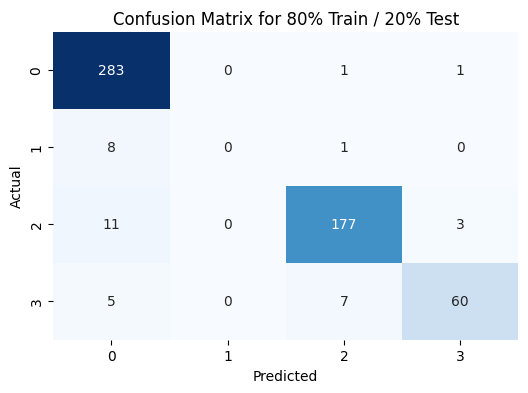

Results for 80% train / 20% test:
Accuracy: 0.9336
F1 Score: 0.9252
----------------------------------------

XGBoost Results:


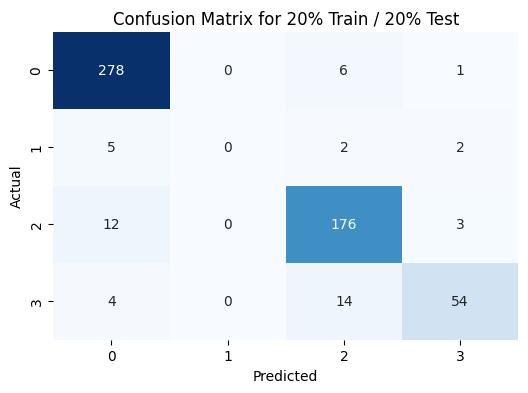

Results for 20% train / 20% test:
Accuracy: 0.9120
F1 Score: 0.9032
----------------------------------------


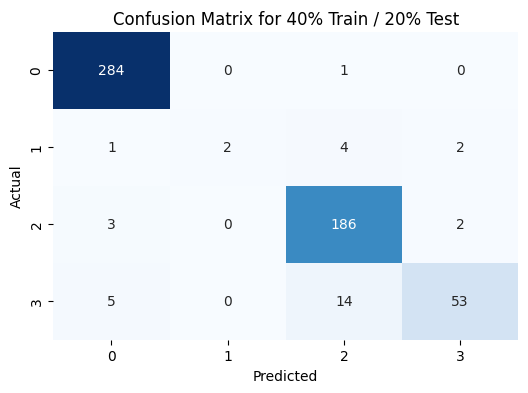

Results for 40% train / 20% test:
Accuracy: 0.9425
F1 Score: 0.9370
----------------------------------------


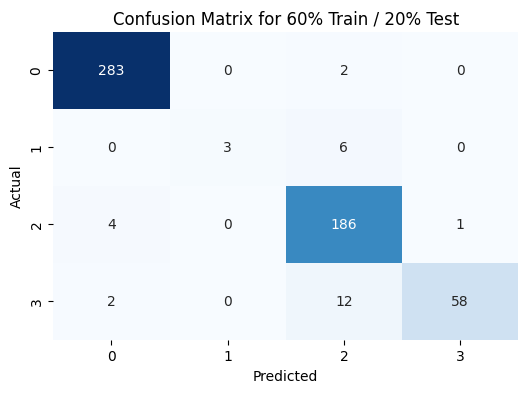

Results for 60% train / 20% test:
Accuracy: 0.9515
F1 Score: 0.9484
----------------------------------------


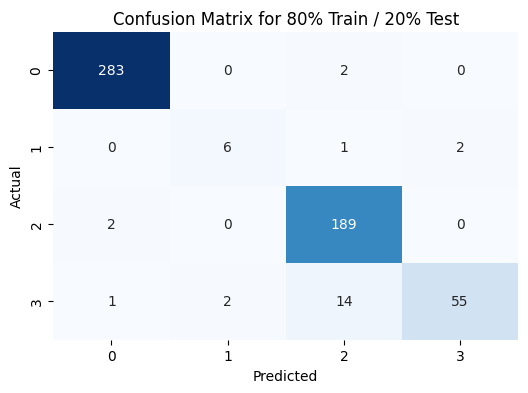

Results for 80% train / 20% test:
Accuracy: 0.9569
F1 Score: 0.9553
----------------------------------------


[{'split': '20% train / 20% test',
  'accuracy': 0.9120287253141831,
  'f1_score': np.float64(0.9031914043658273),
  'confusion_matrix': array([[278,   0,   6,   1],
         [  5,   0,   2,   2],
         [ 12,   0, 176,   3],
         [  4,   0,  14,  54]])},
 {'split': '40% train / 20% test',
  'accuracy': 0.9425493716337523,
  'f1_score': np.float64(0.937035842992627),
  'confusion_matrix': array([[284,   0,   1,   0],
         [  1,   2,   4,   2],
         [  3,   0, 186,   2],
         [  5,   0,  14,  53]])},
 {'split': '60% train / 20% test',
  'accuracy': 0.9515260323159784,
  'f1_score': np.float64(0.9483947790785194),
  'confusion_matrix': array([[283,   0,   2,   0],
         [  0,   3,   6,   0],
         [  4,   0, 186,   1],
         [  2,   0,  12,  58]])},
 {'split': '80% train / 20% test',
  'accuracy': 0.9569120287253142,
  'f1_score': np.float64(0.9553170742601147),
  'confusion_matrix': array([[283,   0,   2,   0],
         [  0,   6,   1,   2],
         [  2,   0

In [48]:
# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
print("KNN Results:")
progressive_validation(knn, x_standardized, y)

# Random Forest Model
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=20)
print("\nRandom Forest Results:")
progressive_validation(rf, x_standardized, y_adjusted)

# XGBoost Model
xgb = XGBClassifier(objective='multi:softmax', learning_rate=0.001, n_estimators=100, random_state=20)
print("\nXGBoost Results:")
progressive_validation(xgb, x_standardized, y_adjusted)

### Run the model without Additional Skirt Info

KNN Results:


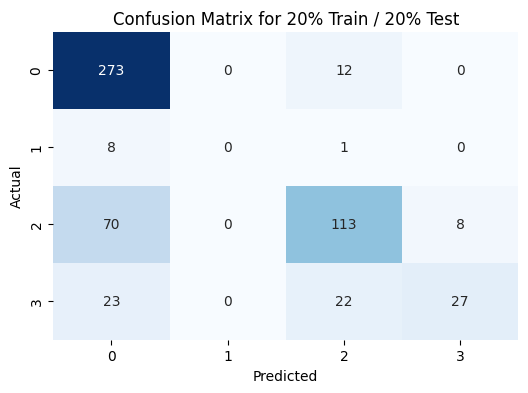

Results for 20% train / 20% test:
Accuracy: 0.7415
F1 Score: 0.7178
----------------------------------------


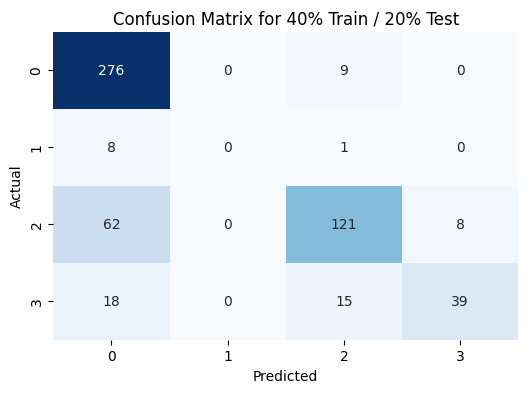

Results for 40% train / 20% test:
Accuracy: 0.7828
F1 Score: 0.7662
----------------------------------------


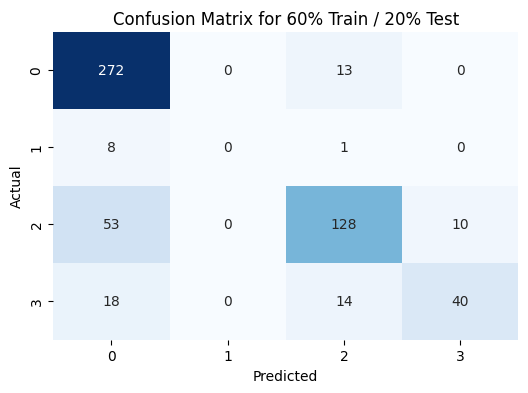

Results for 60% train / 20% test:
Accuracy: 0.7899
F1 Score: 0.7754
----------------------------------------


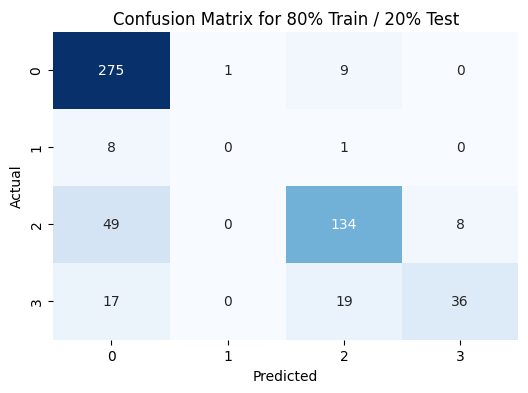

Results for 80% train / 20% test:
Accuracy: 0.7989
F1 Score: 0.7837
----------------------------------------

Random Forest Results:


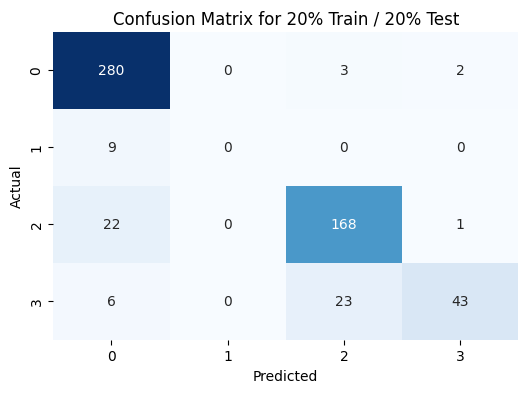

Results for 20% train / 20% test:
Accuracy: 0.8815
F1 Score: 0.8694
----------------------------------------


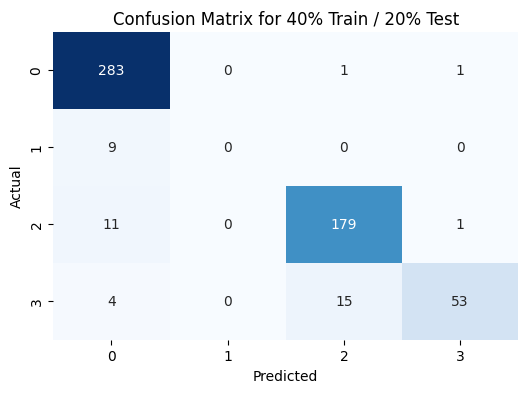

Results for 40% train / 20% test:
Accuracy: 0.9246
F1 Score: 0.9151
----------------------------------------


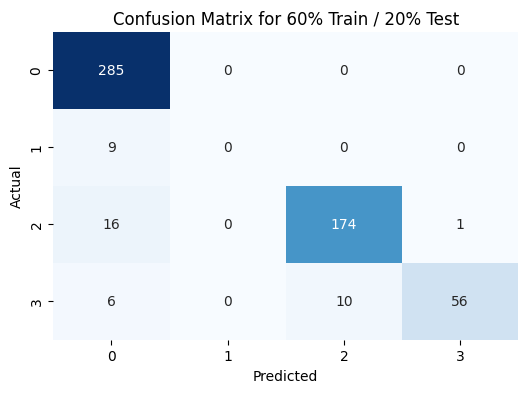

Results for 60% train / 20% test:
Accuracy: 0.9246
F1 Score: 0.9157
----------------------------------------


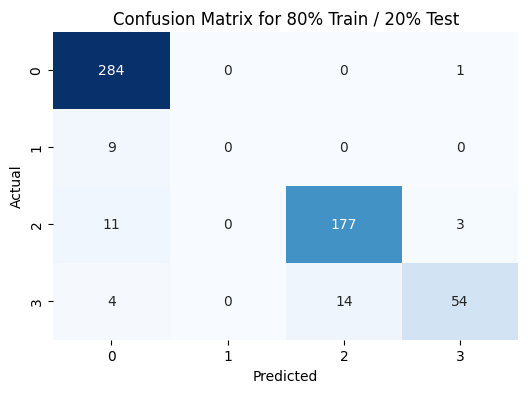

Results for 80% train / 20% test:
Accuracy: 0.9246
F1 Score: 0.9153
----------------------------------------

XGBoost Results:


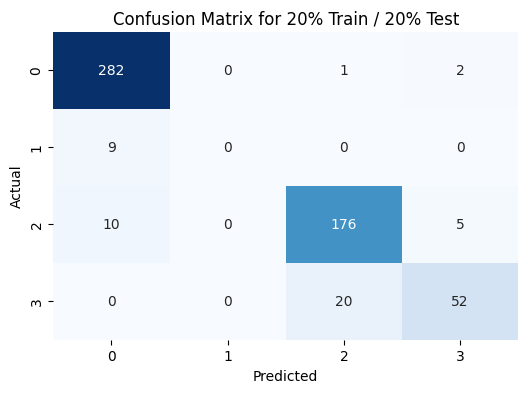

Results for 20% train / 20% test:
Accuracy: 0.9156
F1 Score: 0.9062
----------------------------------------


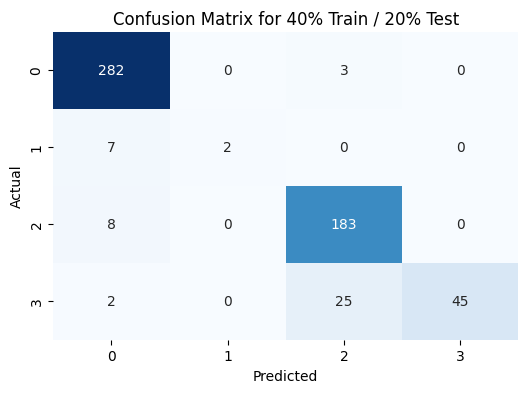

Results for 40% train / 20% test:
Accuracy: 0.9192
F1 Score: 0.9117
----------------------------------------


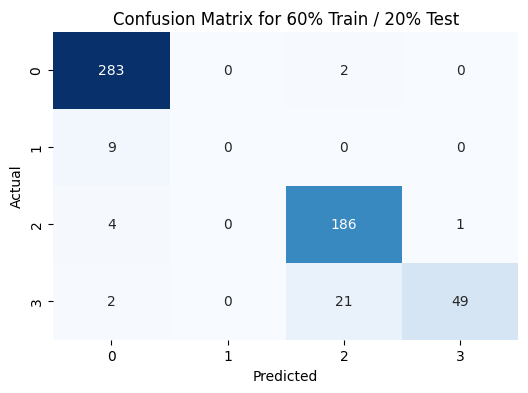

Results for 60% train / 20% test:
Accuracy: 0.9300
F1 Score: 0.9195
----------------------------------------


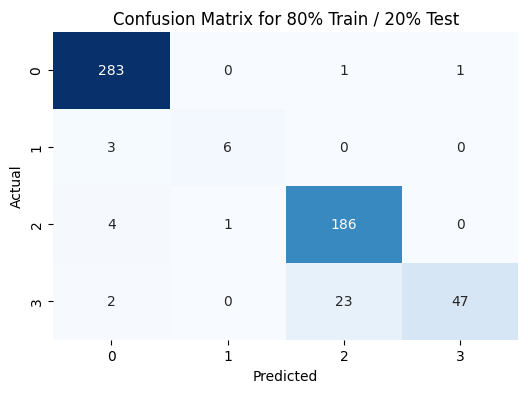

Results for 80% train / 20% test:
Accuracy: 0.9372
F1 Score: 0.9334
----------------------------------------


[{'split': '20% train / 20% test',
  'accuracy': 0.9156193895870736,
  'f1_score': np.float64(0.9061741421111377),
  'confusion_matrix': array([[282,   0,   1,   2],
         [  9,   0,   0,   0],
         [ 10,   0, 176,   5],
         [  0,   0,  20,  52]])},
 {'split': '40% train / 20% test',
  'accuracy': 0.9192100538599641,
  'f1_score': np.float64(0.9116563574017946),
  'confusion_matrix': array([[282,   0,   3,   0],
         [  7,   2,   0,   0],
         [  8,   0, 183,   0],
         [  2,   0,  25,  45]])},
 {'split': '60% train / 20% test',
  'accuracy': 0.9299820466786356,
  'f1_score': np.float64(0.9194894119425253),
  'confusion_matrix': array([[283,   0,   2,   0],
         [  9,   0,   0,   0],
         [  4,   0, 186,   1],
         [  2,   0,  21,  49]])},
 {'split': '80% train / 20% test',
  'accuracy': 0.9371633752244165,
  'f1_score': np.float64(0.9333999225416416),
  'confusion_matrix': array([[283,   0,   1,   1],
         [  3,   6,   0,   0],
         [  4,   

In [49]:
x_standardized = x_standardized.drop(['Feature20'],axis=1)
# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
print("KNN Results:")
progressive_validation(knn, x_standardized, y)

# Random Forest Model
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=20)
print("\nRandom Forest Results:")
progressive_validation(rf, x_standardized, y_adjusted)

# XGBoost Model
xgb = XGBClassifier(objective='multi:softmax', learning_rate=0.001, n_estimators=100, random_state=20)
print("\nXGBoost Results:")
progressive_validation(xgb, x_standardized, y_adjusted)